به نام خدا
ن وا لقلم و ما یسطرون

## 📊 Data Sources and Usage in Model

1. **GDP per capita, PPP (constant 2021 international $)**  
   **Source**: World Bank  
   **Description**:  
   International Comparison Program, World Bank | World Development Indicators database, World Bank | Eurostat-OECD PPP Programme.  
   **Used in model**: *ln-transformed*

2. **International tourism, number of arrivals**  
   **Source**: World Bank  
   **Description**:  
   World Tourism Organization, *Yearbook of Tourism Statistics*, *Compendium of Tourism Statistics*, and data files.  
   **Used in model**: *ln-transformed (dependent variable)*

3. **Political Stability and Absence of Violence/Terrorism: Estimate**  
   **Source**: World Bank  
   **Description**:  
   Measures perceptions of the likelihood of political instability and/or politically-motivated violence, including terrorism.  
   The estimate represents the country's score on the aggregate indicator, expressed in standard normal units, ranging approximately from -2.5 (weak) to 2.5 (strong).  
   **Used in model**: *Raw form (not transformed)*

4. **Official exchange rate (LCU per US$, period average)**  
   **Source**: World Bank  
   **Description**:  
   International Monetary Fund, *International Financial Statistics*.  
   **Used in model**: *ln-transformed*

5. **UNESCO World Heritage Sites (total number)**  
   **Source**: UNESCO World Heritage Centre  
   **URL**: [https://whc.unesco.org/en/list/](https://whc.unesco.org/en/list/)  
   **Used in model**: *Not included directly*

6. **Air transport, passengers carried**  
   **Source**: World Bank (assumed)  
   **Description**: Number of passengers carried by air transport.  
   **Used in model**: *ln-transformed*

7. **`politunesco` (interaction term)**  
   **Description**: Interaction between Political Stability and number of UNESCO World Heritage Sites.  
   **Used in model**: *As a constructed interaction term*

8. **Rule of Law**
  **Source**: Worldwide Governance Indicators (World Bank)
  **Description**: This indicator reflects perceptions of the extent to which agents have confidence in and abide by the rules of society, including the quality of contract enforcement, property rights, the police, and the courts, as well as the likelihood of crime and violence.
  **Used in model**: Raw score or standardized score (specify if applicable)


🌍 سناریو اول: تجارت دوجانبه (Iran → China، Iran → Armenia، ...)


✅ کاربرد:
اینجا تو دنبال ساخت ماتریس وزن فضایی W برای تحلیل پانل فضایی هستی.
یعنی می‌گی: کشورهایی که با هم تجارت بیشتری دارن، به همدیگه اثر می‌ذارن.

🧠 کاربرد:

مدل‌های فضایی بیزین

اثرات سرریزی (spillover)

تحلیل شبکه تجارت (network-based modeling)


🎯 هدف:
برای هر سال، یک ماتریس
𝑊
𝑡
W
t
​
  بسازیم که نشون بده کشورها چقدر با هم تجارت دارن (و نرمال‌سازی کنیم تا جمع

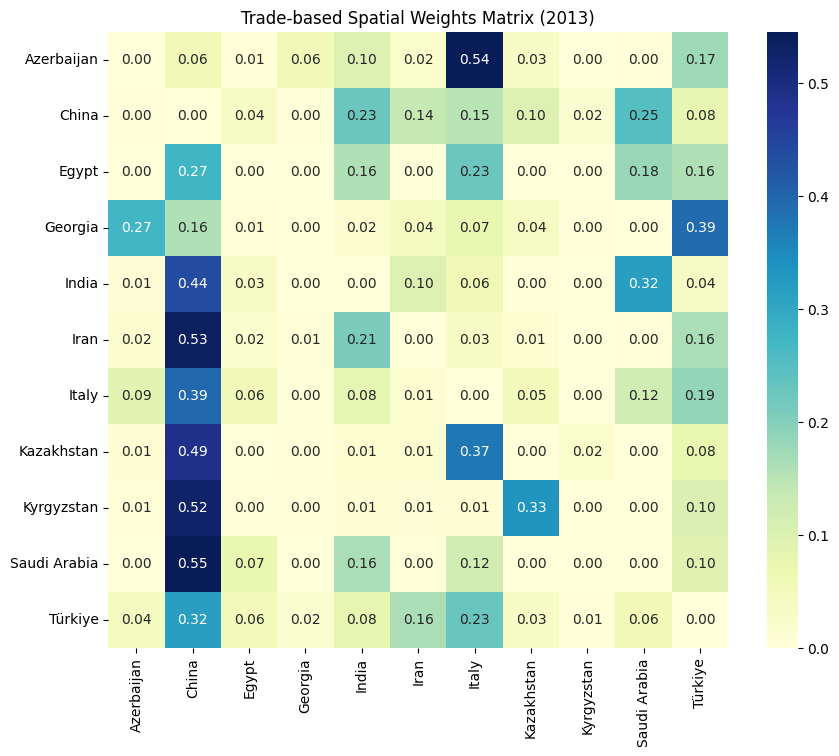

In [ ]:
import pandas as pd
import numpy as np

# داده اولیه
df = pd.read_excel("/content/trade_2002_2019.xlsx")  # یا از قبل داشته باشی

# فقط صادرات رو نگه‌دار (از دید "reporter" به "partner")

df = df[df['flowCode'].isin(['X', 'M'])].copy()


# اسم ستون‌ها رو هماهنگ کن
df.rename(columns={
    'refYear': 'year',
    'reporterDesc': 'from',
    'partnerDesc': 'to',
    'primaryValue': 'value'
}, inplace=True)

# فقط کشورهایی که در تحلیل هستن
selected_countries = [  "Azerbaijan",
    "China",
    "Egypt",
    "Georgia",
    "India",
    "Iran",
    "Italy",
    "Kazakhstan",
    "Kyrgyzstan",
    "Saudi Arabia",
    "Türkiye"]
df = df[df['from'].isin(selected_countries) & df['to'].isin(selected_countries)]

# لیست همه کشورها
countries = sorted(set(df['from']).union(df['to']))
country_to_idx = {country: i for i, country in enumerate(countries)}
n = len(countries)

# ساخت یک دیکشنری از ماتریس‌های W برای هر سال
W_dict = {}


for year in sorted(df['year'].unique()):
    df_y = df[df['year'] == year]

    # ماتریس وزن خام
    W = np.zeros((n, n))

    for _, row in df_y.iterrows():
        i = country_to_idx[row['from']]
        j = country_to_idx[row['to']]
        W[i, j] += row['value']

    # صفر کردن self-trade
    np.fill_diagonal(W, 0)

    # نرمال‌سازی سطری
    row_sums = W.sum(axis=1).reshape(-1, 1)
    W_normalized = np.divide(W, row_sums, out=np.zeros_like(W), where=row_sums!=0)

    W_dict[year] = W_normalized


# اگر بخوای W یک سال خاص رو ببینی مثلاً 2012:
import seaborn as sns
import matplotlib.pyplot as plt

W_sample = W_dict[2013]
plt.figure(figsize=(10, 8))
sns.heatmap(W_sample, xticklabels=countries, yticklabels=countries, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Trade-based Spatial Weights Matrix (2013)")
plt.show()


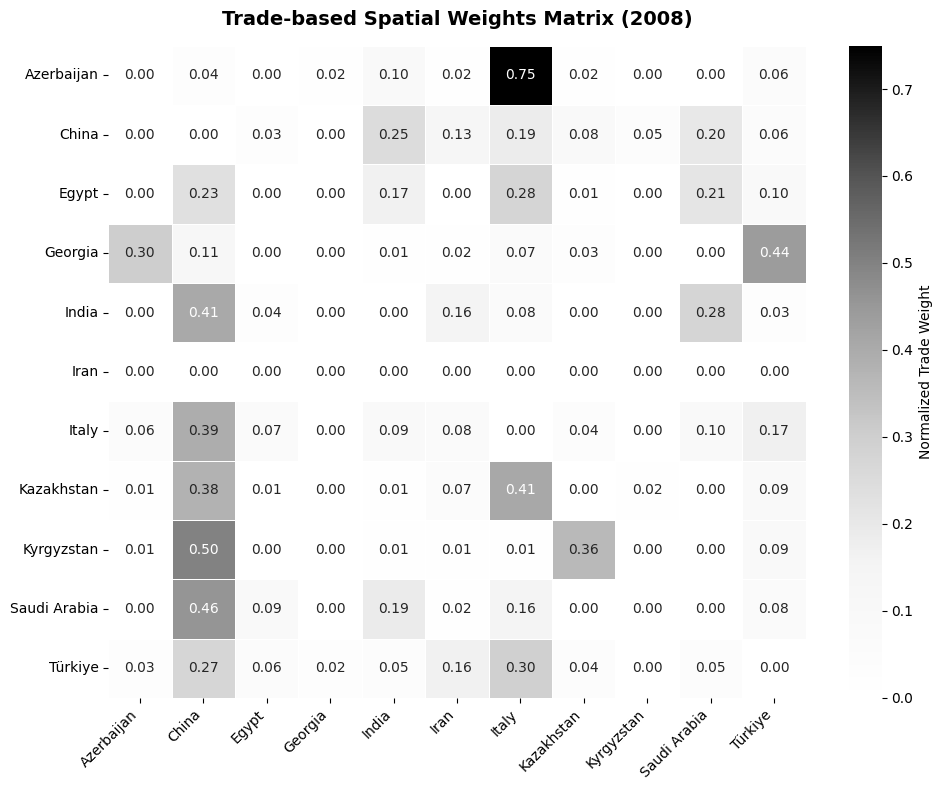

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# تعریف پالت از سفید تا مشکی
gray_cmap = LinearSegmentedColormap.from_list(
    "custom_gray",
    ["#ffffff", "#f5f5f5", "#cfcfcf", "#999999", "#555555", "#000000"]
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    W_dict[2008],
    xticklabels=countries,
    yticklabels=countries,
    cmap=gray_cmap,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Normalized Trade Weight'}
)

plt.title("Trade-based Spatial Weights Matrix (2008)", fontsize=14, weight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

# خروجی با کیفیت بالا
plt.savefig("trade_weights_heatmap_gray.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import pandas as pd

# خواندن فایل CSV
df_sorted = pd.read_excel('FINAL_WIDE_W_14020317.xlsx')

# نمایش چند سطر اول برای اطمینان از درست خواندن
df_sorted

,country,year,GDP,inbound,Political Stability,exchange rate,Airtran,politunesco,Rule of Law: Estimate,unesco
0,Azerbaijan,2002,8.79,13.63,-1.19,-0.03,13.26,-5.93,-0.96,5.0
1,Azerbaijan,2003,8.88,13.85,-0.95,-0.02,13.44,-4.74,-0.88,5.0
2,Azerbaijan,2004,8.96,14.06,-1.06,-0.02,13.82,-5.30,-0.90,5.0
3,Azerbaijan,2005,9.20,13.98,-1.12,-0.06,13.94,-5.62,-0.79,5.0
4,Azerbaijan,2006,9.49,13.99,-1.09,-0.11,14.04,-5.46,-0.89,5.0
...,...,...,...,...,...,...,...,...,...,...
193,Türkiye,2015,10.16,17.53,-1.50,1.00,18.39,-11.96,-0.23,8.0
194,Türkiye,2016,10.18,17.25,-2.01,1.11,18.42,-16.06,-0.34,8.0
195,Türkiye,2017,10.23,17.45,-1.79,1.29,18.50,-14.29,-0.32,8.0
196,Türkiye,2018,10.25,17.65,-1.32,1.57,18.57,-10.52,-0.39,8.0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_sorted['ps_x_unesco_scaled'] = scaler.fit_transform(df_sorted[['politunesco']])

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()


# نرمال‌سازی تعداد سایت‌های یونسکو به بازه [0,1]
df_sorted['unesco_scaled'] = scaler.fit_transform(df_sorted[['unesco']])

df_sorted['rulelaw_scaled'] = (df_sorted['Rule of Law: Estimate'] - df_sorted['Rule of Law: Estimate'].mean()) / df_sorted['Rule of Law: Estimate'].std()

df_sorted['unesco_x_rulelaw'] = df_sorted['unesco_scaled'] * df_sorted['rulelaw_scaled']



df_sorted



df_sorted

,country,year,GDP,inbound,Political Stability,exchange rate,Airtran,politunesco,Rule of Law: Estimate,unesco,ps_x_unesco_scaled,unesco_scaled,rulelaw_scaled,unesco_x_rulelaw
0,Azerbaijan,2002,8.79,13.63,-1.19,-0.03,13.26,-5.93,-0.96,5.0,0.191522,0.035088,-1.100855,-0.038626
1,Azerbaijan,2003,8.88,13.85,-0.95,-0.02,13.44,-4.74,-0.88,5.0,0.252385,0.035088,-0.944155,-0.033128
2,Azerbaijan,2004,8.96,14.06,-1.06,-0.02,13.82,-5.30,-0.90,5.0,0.223744,0.035088,-0.983330,-0.034503
3,Azerbaijan,2005,9.20,13.98,-1.12,-0.06,13.94,-5.62,-0.79,5.0,0.207377,0.035088,-0.767868,-0.026943
4,Azerbaijan,2006,9.49,13.99,-1.09,-0.11,14.04,-5.46,-0.89,5.0,0.215560,0.035088,-0.963743,-0.033816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,Türkiye,2015,10.16,17.53,-1.50,1.00,18.39,-11.96,-0.23,8.0,-0.116882,0.087719,0.329030,0.028862
194,Türkiye,2016,10.18,17.25,-2.01,1.11,18.42,-16.06,-0.34,8.0,-0.326576,0.087719,0.113568,0.009962
195,Türkiye,2017,10.23,17.45,-1.79,1.29,18.50,-14.29,-0.32,8.0,-0.236049,0.087719,0.152743,0.013398
196,Türkiye,2018,10.25,17.65,-1.32,1.57,18.57,-10.52,-0.39,8.0,-0.043233,0.087719,0.015630,0.001371


SDM- Trade Weight Dynamics

 Progress                    Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000    0             0.06        127          135.87 draws/s   0:00:14   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000    0             0.05        127          68.44 draws/s    0:00:29   0:00:00

array([[<Axes: title={'center': 'rho'}>,
        <Axes: title={'center': 'gamma\n0'}>,
        <Axes: title={'center': 'gamma\n1'}>],
       [<Axes: title={'center': 'gamma\n2'}>,
        <Axes: title={'center': 'gamma\n3'}>, <Axes: >]], dtype=object)

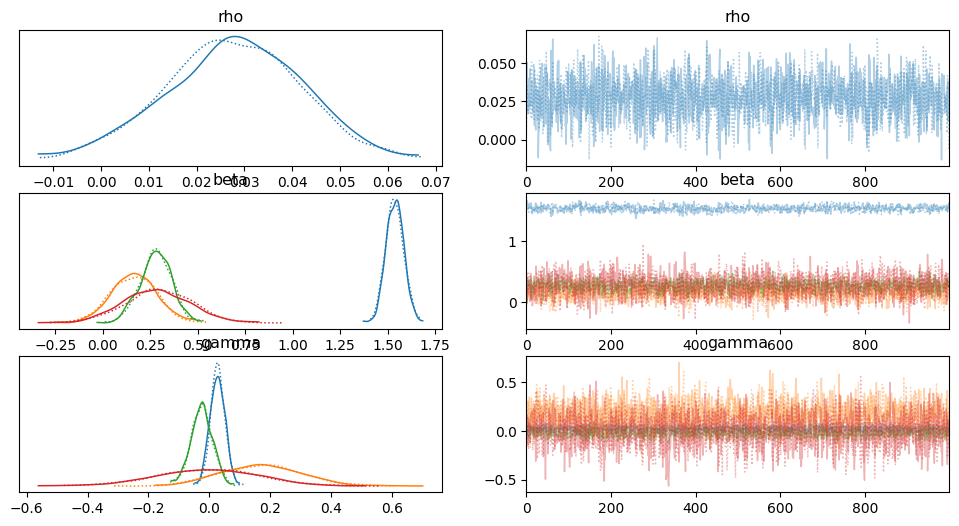

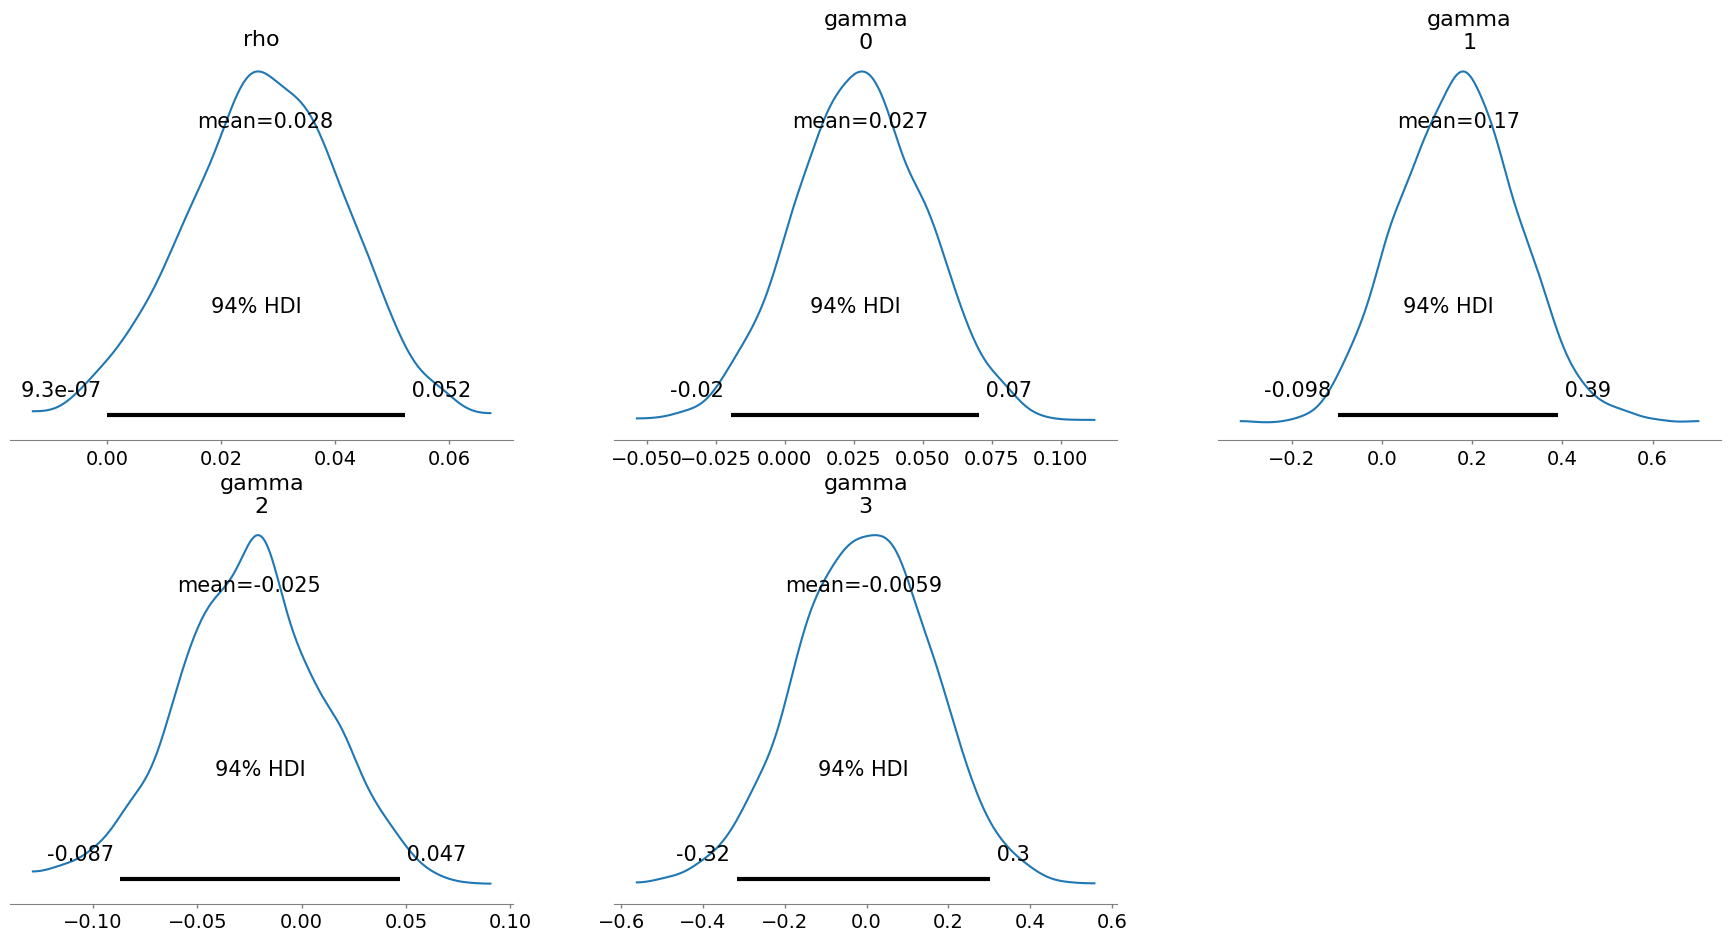

In [ ]:
X = df_sorted[['GDP', 'Political Stability', 'exchange rate',"Rule of Law: Estimate"]].values

K = X.shape[1]  # تعداد متغیرهای مستقل
N = df_sorted.shape[0]  # تعداد کل ردیف‌های داده (نمونه‌ها)
y = df_sorted['inbound'].values

import pymc as pm
import arviz as az
import pandas as pd
import numpy as np

# فرض: df_sorted شامل country، year، inbound و متغیرهای توضیحی (مثل GDP، ثبات سیاسی)
# X: آرایه NumPy (N*T × K)
# y: آرایه NumPy (گردشگری ورودی، N*T × 1)
# W_dict: دیکشنری ماتریس‌های وزنی تجارت برای هر سال

# مرحله 1: آماده‌سازی داده‌ها
countries = sorted(df_sorted['country'].unique())
country_to_idx = {c: i for i, c in enumerate(countries)}
years = sorted(df_sorted['year'].unique())
year_to_idx = {y: i for i, y in enumerate(years)}
N = len(countries)  # 12 کشور
T = len(years)      # 17 سال
K = X.shape[1]      # تعداد متغیرهای توضیحی

# ساخت y_neighbors (Wy) و WX
y_neighbors = []
WX = np.zeros((N * T, K))

for idx, row in df_sorted.iterrows():
    year = row['year']
    country = row['country']
    c_idx = country_to_idx[country]
    y_idx = year_to_idx[year]
    obs_idx = y_idx * N + c_idx

    # ماتریس وزنی سال
    W = W_dict[year]

    # y در آن سال
    y_t = df_sorted[df_sorted['year'] == year].set_index('country').loc[countries]['inbound'].values

    # محاسبه Wy
    wy = np.dot(W[c_idx], y_t)
    y_neighbors.append(wy)

    # محاسبه WX (با آرایه X)
    X_t = X[y_idx * N:(y_idx + 1) * N]  # X برای سال جاری
    WX[obs_idx] = np.dot(W[c_idx], X_t)

y_neighbors = np.array(y_neighbors)

# مرحله 2: مدل SDM
with pm.Model() as sdm_model:
    beta = pm.Normal("beta", mu=0, sigma=10, shape=K)
    gamma = pm.Normal("gamma", mu=0, sigma=10, shape=K)  # ضرایب WX
    alpha = pm.Normal("alpha", mu=0, sigma=1, shape=N)
    rho = pm.Normal("rho", mu=0, sigma=1)
    sigma = pm.HalfCauchy("sigma", beta=2)

    country_idx = pd.Categorical(df_sorted['country']).codes
    mu = pm.math.dot(X, beta) + pm.math.dot(WX, gamma) + alpha[country_idx] + rho * y_neighbors

    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    trace = pm.sample(1000, tune=1000, target_accept=0.9, return_inferencedata=True)

# مرحله 3: خروجی
summary = az.summary(trace, var_names=["rho", "beta", "gamma", "sigma", "alpha"])
summary
az.plot_trace(trace, var_names=["rho", "beta", "gamma"])
az.plot_posterior(trace, var_names=["rho", "gamma"])

In [ ]:
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
rho,0.028,0.014,0.000,0.052,0.000,0.000,2296.0,1557.0,1.00
beta[0],1.539,0.047,1.453,1.625,0.002,0.001,902.0,1305.0,1.01
beta[1],0.163,0.120,-0.051,0.399,0.003,0.003,1533.0,1233.0,1.00
beta[2],0.279,0.083,0.116,0.426,0.003,0.002,926.0,912.0,1.00
beta[3],0.287,0.177,-0.051,0.606,0.005,0.004,1415.0,1358.0,1.00
gamma[0],0.027,0.024,-0.020,0.070,0.001,0.001,1915.0,1358.0,1.00
gamma[1],0.171,0.132,-0.098,0.390,0.003,0.003,1934.0,1491.0,1.00
gamma[2],-0.025,0.035,-0.087,0.047,0.001,0.001,1188.0,1159.0,1.00
gamma[3],-0.006,0.166,-0.317,0.303,0.005,0.004,1332.0,1345.0,1.00
sigma,0.428,0.023,0.386,0.471,0.001,0.001,1740.0,1495.0,1.00


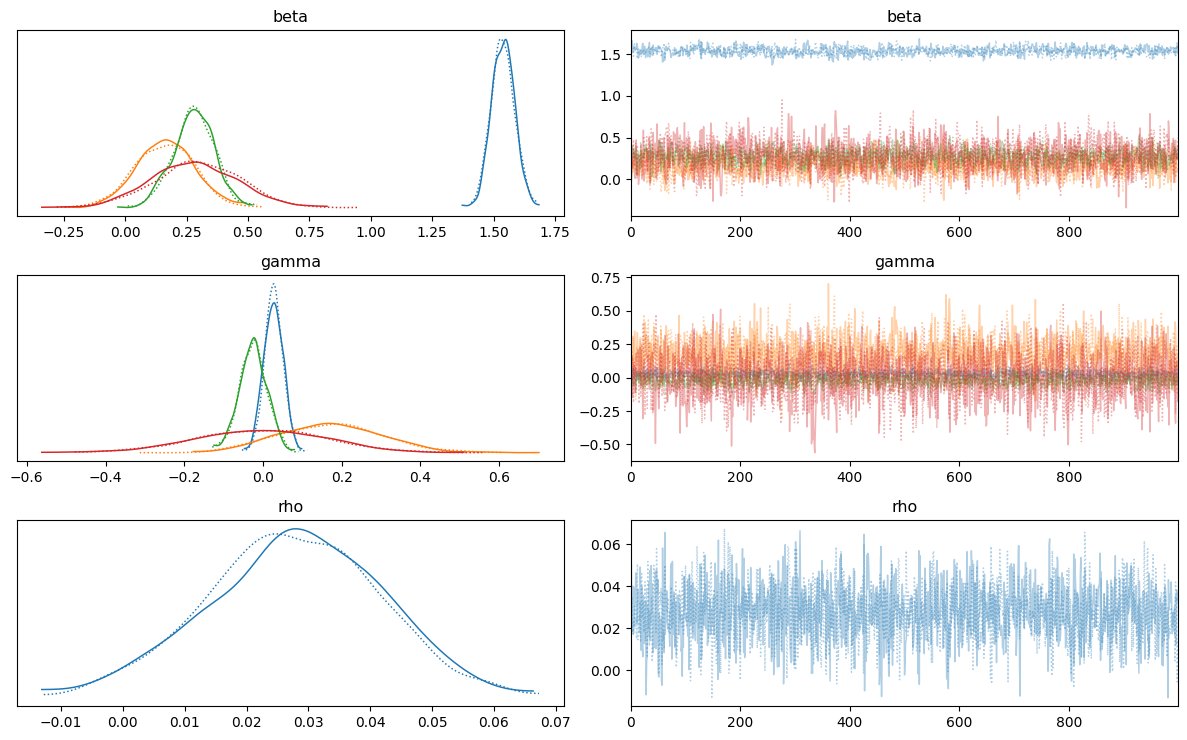

In [ ]:
import arviz as az
import matplotlib.pyplot as plt

# نام متغیرهای مدل که می‌خواهیم به صورت خوانا بنویسیم
param_labels = {
    'beta[0]': 'GDP',
    'beta[1]': 'Political Stability',
    'beta[2]': 'Exchange Rate',
    'beta[3]': 'Air Transport',
    'beta[4]': 'Political Stability × UNESCO',
    'gamma[0]': 'Dynamic Trade-Weighted GDP',
    'gamma[1]': 'Dynamic Trade-Weighted Political Stability',
    'gamma[2]': 'Dynamic Trade-Weighted Exchange Rate',
    'gamma[3]': 'Dynamic Trade-Weighted Air Transport',
    'gamma[4]': 'Dynamic Trade-Weighted Political Stability × UNESCO',
    'rho': 'Spatial Autocorrelation (rho)',
    'sigma': 'Sigma'
}

# تابع برای تغییر برچسب‌های x در نمودار trace
def custom_traceplot(trace, var_names):
    az.plot_trace(trace, var_names=var_names, figsize=(12, len(var_names)*2.5))

    axes = plt.gcf().axes
    for ax in axes:
        label = ax.get_xlabel()
        if label in param_labels:
            ax.set_xlabel(param_labels[label], fontsize=12, color='darkblue')
    plt.tight_layout()
    plt.show()


# استفاده
custom_traceplot(trace, var_names=['beta', 'gamma', 'rho'])

<ipython-input-10-445108070>:10: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  alpha_hdi = az.hdi(alpha_samples.T, hdi_prob=0.94)  # شکل: (N کشور, 2)


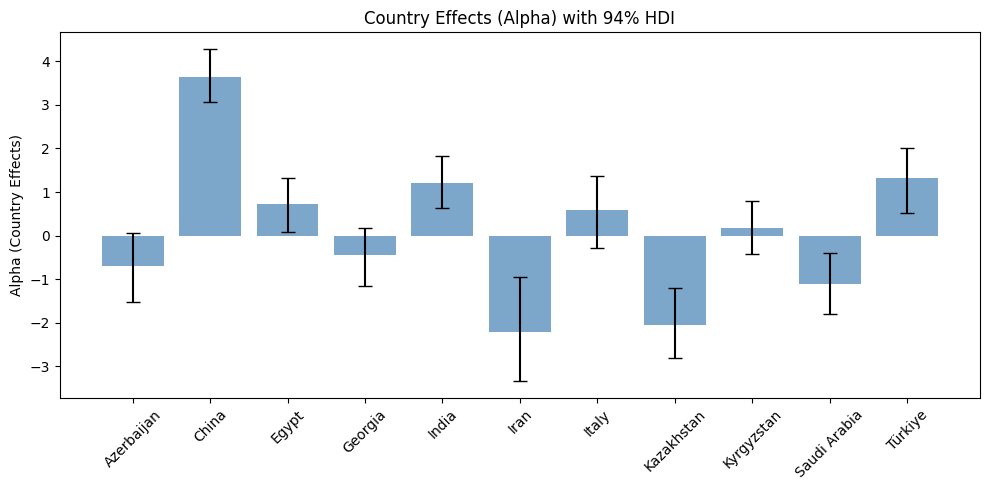

In [ ]:
import matplotlib.pyplot as plt
import arviz as az
import numpy as np

# استخراج اثرات کشوری (alpha) از trace
alpha_samples = trace.posterior["alpha"].stack(draws=("chain", "draw")).values  # شکل: (N کشور, نمونه‌ها)

# محاسبه میانگین و HDI
alpha_means = alpha_samples.mean(axis=1)
alpha_hdi = az.hdi(alpha_samples.T, hdi_prob=0.94)  # شکل: (N کشور, 2)

# داده‌های نمودار
countries_ordered = sorted(country_to_idx.keys())
lower_bounds = alpha_hdi[:, 0]
upper_bounds = alpha_hdi[:, 1]

# رسم نمودار میله‌ای با خطای HDI
fig, ax = plt.subplots(figsize=(10, 5))
errors = [alpha_means - lower_bounds, upper_bounds - alpha_means]
ax.bar(countries_ordered, alpha_means, yerr=errors, capsize=5, color='steelblue', alpha=0.7)

# تنظیمات ظاهری
ax.set_ylabel("Alpha (Country Effects)")
ax.set_title("Country Effects (Alpha) with 94% HDI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(False)
plt.show()



In [ ]:
countries = {
    'Azerbaijan': (40.4093, 49.8671),       # Baku
    'China': (34.3416, 108.9398),           # Xi'an
    'Egypt': (27.1800, 31.1837),            # Assiut
    'Georgia': (42.2679, 42.7180),          # Kutaisi
    'India': (21.1466, 79.0889),            # Nagpur
    'Iran': (35.5760, 53.3950),             # Semnan
    'Italy': (45.4408, 12.3155),            # Venice
    'Kazakhstan': (47.0945, 51.9237),       # Aktau
    'Kyrgyzstan': (40.5300, 72.8000),       # Osh
    'Saudi Arabia': (21.4858, 39.1925),     # Jeddah
    'Türkiye': (40.1826, 29.0662),          # Bursa
}
